In [1]:
from datetime import datetime

print(f"Timestamp: {datetime.now()}")

Timestamp: 2025-12-08 10:49:38.922720


# QC Filters

**Pinned Environment:** [`envs/sc-spatial.yaml`](../.../envs/sc-spatial.yaml)  

* Transcript count floor: Increased to 50 reads / cell
* Transcript count ceiling: just remove cells in top quarter of percent for each sample
* Area: No threshold
* Doublet scores: No threshold (relatively uninformative)

In [2]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import sys
import session_info

### Set paths, import data

In [3]:
base_dir = Path('/home/workspace/projects/drg')
input_dir = base_dir / 'data/h5ad/export_01/01a_raw/output_folder'
output_dir = base_dir / "data/h5ad/export_01/01b_filter"

output_dir.mkdir(parents=True, exist_ok=True)

Make a list of files in the directory:

In [4]:
sample_list = os.listdir(input_dir)
sample_list

['TMA00304.h5ad',
 'TMA00306.h5ad',
 'TMA00313.h5ad',
 'TMA00311.h5ad',
 'TMA00308.h5ad',
 'TMA00303.h5ad',
 'TMA00310.h5ad',
 'TMA00305.h5ad',
 'TMA00309.h5ad',
 'TMA00307.h5ad',
 'TMA00312.h5ad',
 'TMA00314.h5ad']

Add samples to list if they end in .h5ad:

In [5]:
sample_files = [
    os.path.join(input_dir, f)
    for f in os.listdir(input_dir)
    if f.endswith(".h5ad") and f.startswith("TMA")
]

adata_list = [ad.read_h5ad(f) for f in sample_files]

for f, adata in zip(sample_files, adata_list):
    print(f"{os.path.basename(f)} > {adata.n_obs:,} cells × {adata.n_vars:,} genes")

TMA00304.h5ad > 24,375 cells × 480 genes
TMA00306.h5ad > 37,315 cells × 480 genes
TMA00313.h5ad > 20,275 cells × 480 genes
TMA00311.h5ad > 24,803 cells × 480 genes
TMA00308.h5ad > 9,759 cells × 480 genes
TMA00303.h5ad > 12,755 cells × 480 genes
TMA00310.h5ad > 1,931 cells × 480 genes
TMA00305.h5ad > 38,753 cells × 480 genes
TMA00309.h5ad > 4,012 cells × 480 genes
TMA00307.h5ad > 9,238 cells × 480 genes
TMA00312.h5ad > 21,826 cells × 480 genes
TMA00314.h5ad > 17,792 cells × 480 genes


## Filter

Filtering based on total cell count thresholds from Max's paper.

In [6]:
def plot_violin_subplots(adata_list, obs_keys):
    n = len(adata_list)
    fig, axs = plt.subplots(1, n, figsize=(6 * n, 5))
    
    if n == 1:
        axs = [axs]  # make iterable if only one sample

    for ax, adata in zip(axs, adata_list):
        sc.pl.violin(adata, obs_keys, show=False, ax=ax)
        ax.set_title(getattr(adata, 'filename', 'Sample'))

    plt.tight_layout()
    plt.show()

/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` 

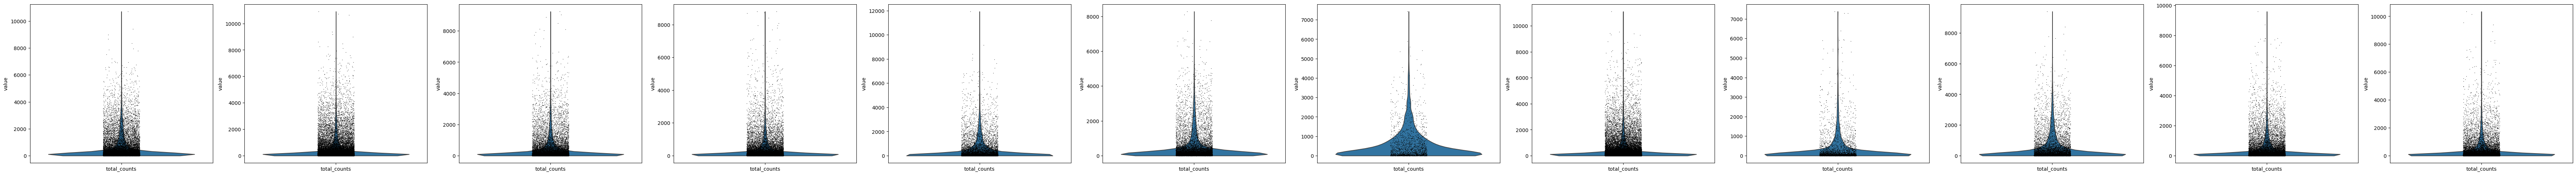

In [7]:
plot_violin_subplots(adata_list, ['total_counts'])

In [8]:
# Total counts – Floor threshold
for i, adata in enumerate(adata_list):
    sample_id = adata.obs["sample_id"].unique()[0]
    print(f"{sample_id} shape before total_counts floor threshold: {adata.shape}")
    adata_list[i] = adata[adata.obs['total_counts'] > 50].copy()
    print(f"{sample_id} shape after total_counts floor threshold: {adata_list[i].shape}")

TMA00304 shape before total_counts floor threshold: (24375, 480)
TMA00304 shape after total_counts floor threshold: (18585, 480)
TMA00306 shape before total_counts floor threshold: (37315, 480)
TMA00306 shape after total_counts floor threshold: (26454, 480)
TMA00313 shape before total_counts floor threshold: (20275, 480)
TMA00313 shape after total_counts floor threshold: (12707, 480)
TMA00311 shape before total_counts floor threshold: (24803, 480)
TMA00311 shape after total_counts floor threshold: (14640, 480)
TMA00308 shape before total_counts floor threshold: (9759, 480)
TMA00308 shape after total_counts floor threshold: (5419, 480)
TMA00303 shape before total_counts floor threshold: (12755, 480)
TMA00303 shape after total_counts floor threshold: (9700, 480)
TMA00310 shape before total_counts floor threshold: (1931, 480)
TMA00310 shape after total_counts floor threshold: (1400, 480)
TMA00305 shape before total_counts floor threshold: (38753, 480)
TMA00305 shape after total_counts flo

In [9]:
# Total counts - ceiling threshold
for i, adata in enumerate(adata_list):
    sample_id = adata.obs["sample_id"].unique()[0]
    print(f"{sample_id} shape before total_counts ceiling threshold: {adata.shape}")
    total_counts_ceiling = adata.obs["total_counts"].quantile(0.9975)
    adata_list[i] = adata[adata.obs["total_counts"] < total_counts_ceiling, :].copy()
    print(f"{sample_id} shape after total_counts ceiling threshold: {adata_list[i].shape}")

TMA00304 shape before total_counts ceiling threshold: (18585, 480)
TMA00304 shape after total_counts ceiling threshold: (18538, 480)
TMA00306 shape before total_counts ceiling threshold: (26454, 480)
TMA00306 shape after total_counts ceiling threshold: (26387, 480)
TMA00313 shape before total_counts ceiling threshold: (12707, 480)
TMA00313 shape after total_counts ceiling threshold: (12675, 480)
TMA00311 shape before total_counts ceiling threshold: (14640, 480)
TMA00311 shape after total_counts ceiling threshold: (14603, 480)
TMA00308 shape before total_counts ceiling threshold: (5419, 480)
TMA00308 shape after total_counts ceiling threshold: (5405, 480)
TMA00303 shape before total_counts ceiling threshold: (9700, 480)
TMA00303 shape after total_counts ceiling threshold: (9675, 480)
TMA00310 shape before total_counts ceiling threshold: (1400, 480)
TMA00310 shape after total_counts ceiling threshold: (1396, 480)
TMA00305 shape before total_counts ceiling threshold: (26610, 480)
TMA00305

/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` 

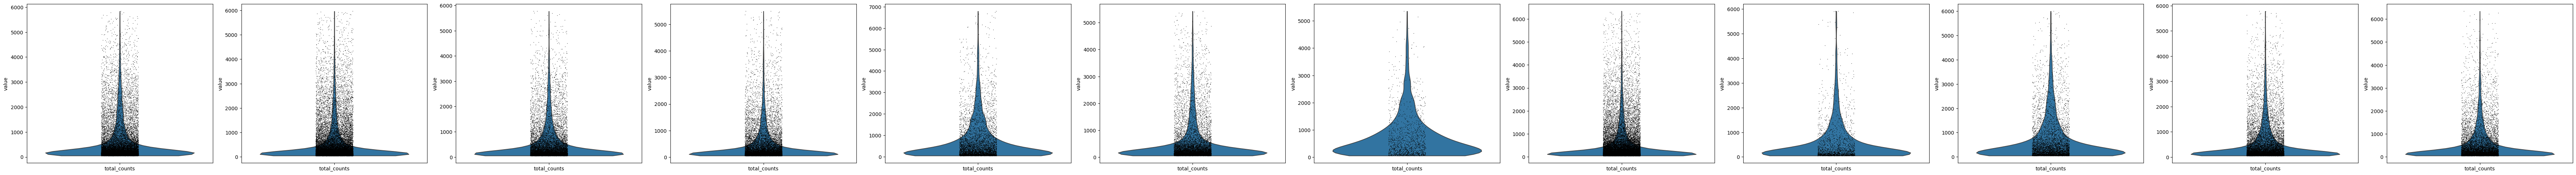

In [10]:
plot_violin_subplots(adata_list, ['total_counts'])

## Concatenate

In [11]:
adata = ad.concat(adata_list, 
                  join="outer", 
                  label = 'batch',
                  index_unique="-")

In [12]:
adata

AnnData object with n_obs × n_vars = 147036 × 480
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'output_id', 'region_id', 'slide_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'batch'
    obsm: 'spatial'

In [13]:
adata.obs.sample_id.value_counts()

sample_id
TMA00305    26543
TMA00306    26387
TMA00304    18538
TMA00311    14603
TMA00312    13561
TMA00313    12675
TMA00314    10710
TMA00303     9675
TMA00307     5574
TMA00308     5405
TMA00309     1969
TMA00310     1396
Name: count, dtype: int64

## Normalization

In [14]:
adata.layers["counts"] = adata.X.copy()

In [15]:
def remove_transgenes(adata, pattern="Seq"):
    print(f"\nProcessing: {getattr(adata, 'uns', {}).get('name', 'AnnData')}")
    print(f"Initial # genes: {adata.n_vars}")

    # Identify transgenes (always exactly five)
    transgenes = adata.var_names[adata.var_names.str.contains(pattern, case=False, na=False)]
    print(f"Transgenes: {list(transgenes)}")

    # Remove them
    adata_filtered = adata[:, ~adata.var_names.isin(transgenes)].copy()
    print(f"Remaining genes: {adata_filtered.n_vars}")

    return adata_filtered

adata_subset = remove_transgenes(adata, pattern="Seq")


Processing: AnnData
Initial # genes: 480
Transgenes: ['Cre_Seq5', 'EGFP_Seq1', 'Flp_Seq4', 'mCherry_Seq3', 'tdTomato_Seq2']
Remaining genes: 475


In [16]:
sc.pp.normalize_total(adata_subset)
adata_subset.layers["normalized"] = adata_subset.X.copy()

sc.pp.log1p(adata_subset)
adata_subset.raw = adata_subset.copy()
adata_subset.layers["log1p"] = adata_subset.X.copy()

In [17]:
print(adata.layers)
print(adata_subset.layers)

Layers with keys: counts
Layers with keys: counts, normalized, log1p


## Export

In [18]:
# 480 genes
filename = os.path.join(output_dir, 'adata-480.h5ad')
os.makedirs(os.path.dirname(filename), exist_ok=True)
adata.write_h5ad(filename, compression='gzip')
print(f'Filtered AnnData with all genes saved to: {filename}')

# 475 genes
filename = os.path.join(output_dir, 'adata-475.h5ad')
os.makedirs(os.path.dirname(filename), exist_ok=True)
adata_subset.write_h5ad(filename, compression='gzip')
print(f'Filtered AnnData without transgenes saved to: {filename}')

Filtered AnnData with all genes saved to: /home/workspace/projects/drg/data/h5ad/export_01/01b_filter/adata-480.h5ad
Filtered AnnData without transgenes saved to: /home/workspace/projects/drg/data/h5ad/export_01/01b_filter/adata-475.h5ad


## Session info

In [19]:
print('active conda environment:', os.path.basename(sys.prefix))
session_info.show()

active conda environment: sc-spatial
